# Fase 3 — Extracción de features

Este notebook **no calcula nada nuevo**: consume `src/features.py` y la matriz ya generada
(`data_processed/features.parquet`) para **verla y auditarla**. La maquinaria vive en el módulo,
la exploración vive aquí (convención del finding 014).

Lo que se revisa, en orden:

1. **El contrato de la matriz** — forma, columnas, ausencia de NaN/inf, balance de clases.
2. **La invarianza a escala** — la restricción metodológica dura de la Fase 3, demostrada con datos reales.
3. **El espectro** — la PSD de una época real con las cinco bandas marcadas: de aquí sale la mitad de las features.
4. **Distribuciones por clase** — cómo se separan (o no) *good* y *poor*.
5. **Correlación entre features** — cuánta información redundante estamos metiendo en la Fase 4.
6. **Comparación por paciente** — el nivel de análisis que de verdad importa: N=17, no N=34 000.

In [1]:
import sys
from pathlib import Path

# El notebook vive en development/notebooks/; la maquinaria en development/src/.
NB_DIR = Path.cwd()
DEV_DIR = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
sys.path.insert(0, str(DEV_DIR / "src"))

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns

import features as F

mne.set_log_level("ERROR")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)

print("features module:", F.__file__)
print("feature families:", len(F.feature_names()))

features module: /home/singular1ty/Documents/projects/ongoing_projects/eeg-ml-project/development/src/features.py
feature families: 20


## 1. La matriz de features y su contrato

El contrato con la Fase 4 es literal: una fila por época; `patient_id` (el vector `groups` de la
validación cruzada agrupada), `label` (la `y`), `outcome`, `epoch_idx`, y después todas las
`<feature>_<canal>` en float. Sin NaN ni inf.

In [2]:
df = pd.read_parquet(F.FEATURES_PATH)
META_COLS = ["patient_id", "label", "outcome", "epoch_idx"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

print(f"shape             : {df.shape[0]} rows x {df.shape[1]} cols")
print(f"feature columns   : {len(FEATURE_COLS)}  ({len(F.feature_names())} families x 19 channels)")
print(f"patients          : {df.patient_id.nunique()}")
print(f"epochs / patient  : {df.groupby('patient_id').size().unique()}")
print(f"NaN / inf         : {int(df[FEATURE_COLS].isna().sum().sum())} / "
      f"{int(np.isinf(df[FEATURE_COLS].to_numpy()).sum())}")
print(f"class balance     : {df.groupby('label').patient_id.nunique().to_dict()} patients | "
      f"{df.label.value_counts().to_dict()} epochs")
df[META_COLS].head()

shape             : 34000 rows x 384 cols
feature columns   : 380  (20 families x 19 channels)
patients          : 17
epochs / patient  : [2000]
NaN / inf         : 0 / 0
class balance     : {0: 8, 1: 9} patients | {1: 18000, 0: 16000} epochs


,patient_id,label,outcome,epoch_idx
0,0284,1,Good,0
1,0284,1,Good,1
2,0284,1,Good,2
3,0284,1,Good,3
4,0284,1,Good,4


In [3]:
# Etiqueta por paciente: cada paciente tiene UNA sola clase (si no, habría un error grave
# de alineación entre épocas y etiquetas).
patient_label = df.groupby("patient_id")[["label", "outcome"]].agg(
    {"label": "nunique", "outcome": "first"}
)
assert (patient_label["label"] == 1).all(), "A patient has more than one label"
print(patient_label["outcome"].value_counts().to_string())

# Ayuda de lectura: colapsa los 19 canales de una familia en su promedio.
# SOLO para VISUALIZAR — el modelo de la Fase 4 recibe los 19 canales por separado.
def channel_mean(frame: pd.DataFrame, feature: str) -> pd.Series:
    cols = [c for c in frame.columns if c.rsplit("_", 1)[0] == feature]
    return frame[cols].mean(axis=1)


avg = pd.DataFrame({f: channel_mean(df, f) for f in F.feature_names()})
avg[META_COLS] = df[META_COLS]
avg.head()

outcome
Good    9
Poor    8


,rel_delta,rel_theta,rel_alpha,rel_beta,rel_gamma,ratio_alpha_delta,ratio_theta_alpha,ratio_alpha_theta,dtabr,spectral_entropy,...,hjorth_complexity,line_length_norm,zero_crossing_rate,kurtosis,skewness,perm_entropy,patient_id,label,outcome,epoch_idx
0,0.859728,0.097100,0.029601,0.011905,0.001666,0.035084,3.447262,0.349741,25.507123,0.460001,...,5.340206,135.778774,0.065170,1.834509,0.064309,0.920247,0284,1,Good,0
1,0.899378,0.068629,0.019292,0.011265,0.001436,0.021652,3.698478,0.305958,34.805768,0.403580,...,5.609888,131.553511,0.057110,1.987761,0.242109,0.923664,0284,1,Good,1
2,0.760961,0.151254,0.065938,0.019290,0.002558,0.087719,2.350355,0.467711,11.180589,0.568489,...,4.000943,171.773266,0.071176,2.423073,0.177097,0.920926,0284,1,Good,2
3,0.711504,0.208333,0.054623,0.022980,0.002560,0.083910,4.360989,0.312844,13.908423,0.546224,...,4.582387,142.176863,0.075233,2.901664,0.139713,0.923376,0284,1,Good,3
4,0.882696,0.080817,0.020525,0.013139,0.002822,0.023627,4.118031,0.262914,32.506380,0.422727,...,6.180264,122.600021,0.068121,2.059976,0.086220,0.904861,0284,1,Good,4


## 2. Invarianza a escala — la restricción dura de la Fase 3

Las amplitudes de I-CARE están en `'nu'` (normalizadas, **sin calibrar**) y el factor de escala
puede diferir entre pacientes. Si una feature cambia al multiplicar la señal por una constante
`k`, el modelo puede aprender la **calibración del equipo** en vez de la fisiología — un error que
no lanza excepción, solo devuelve métricas engañosas.

El test recalcula **todas** las features sobre datos reales multiplicados por `k` y exige
igualdad numérica. Se barren varios órdenes de magnitud a propósito (`1e3 … 1e-8`): un factor
moderado no detecta los umbrales absolutos escondidos, que es justo el fallo que se busca.

In [4]:
invariance = F.scale_invariance_report(fif_paths=F.development_fif_paths()[:3], n_epochs=50)
print(invariance.to_string(index=False))
print("\nALL PASS:", bool((invariance.verdict == "PASS").all()))

           feature  max_rel_diff verdict
         rel_delta  2.677849e-15    PASS
         rel_theta  2.969135e-15    PASS
         rel_alpha  2.917035e-15    PASS
          rel_beta  3.771789e-15    PASS
         rel_gamma  3.279390e-15    PASS
 ratio_alpha_delta  1.455232e-15    PASS
 ratio_theta_alpha  1.136960e-15    PASS
 ratio_alpha_theta  1.170844e-15    PASS
             dtabr  1.365148e-15    PASS
  spectral_entropy  2.620890e-15    PASS
             sef95  9.148773e-14    PASS
             sef50  2.084596e-14    PASS
 spectral_centroid  3.517772e-15    PASS
   hjorth_mobility  6.196481e-16    PASS
 hjorth_complexity  1.004672e-15    PASS
  line_length_norm  5.665162e-16    PASS
zero_crossing_rate  0.000000e+00    PASS
          kurtosis  5.706214e-12    PASS
          skewness  2.391610e-12    PASS
      perm_entropy  0.000000e+00    PASS

ALL PASS: True


In [5]:
# CONTROL NEGATIVO: el test solo vale si es capaz de SUSPENDER a alguien.
# Estas tres features son las que se descartaron por depender de la escala; se recalculan
# aquí a mano para mostrar cómo se comportan bajo k=10 (deberían multiplicarse, no quedarse igual).
epochs_demo = mne.read_epochs(F.development_fif_paths()[0], preload=True, verbose="ERROR")
data_demo = epochs_demo.get_data()[:100]

rejected = {
    "hjorth_activity (variance)": lambda x: x.var(axis=-1),
    "line_length (raw)": lambda x: np.abs(np.diff(x, axis=-1)).sum(axis=-1),
    "absolute band power": lambda x: F.compute_welch_psd(x)[1].sum(axis=-1),
}
rows = []
for name, fn in rejected.items():
    ref, scaled = fn(data_demo), fn(data_demo * 10.0)
    rows.append({"rejected feature": name,
                 "ratio at k=10": float(np.median(scaled / ref)),
                 "invariant?": bool(np.allclose(ref, scaled))})
pd.DataFrame(rows)

,rejected feature,ratio at k=10,invariant?
0,hjorth_activity (variance),100.0,False
1,line_length (raw),10.0,False
2,absolute band power,100.0,False


In [6]:
# ¿ES REAL EL PROBLEMA DE ESCALA, o una precaución teórica? Se mide la amplitud típica
# (desviación estándar mediana por época) de cada paciente. Si el rango entre pacientes fuera
# estrecho, la potencia absoluta sería defendible; si abarca órdenes de magnitud, no lo es.
# OJO: esto es un DIAGNÓSTICO, no una feature — la amplitud absoluta jamás entra en la matriz.
amplitude = []
for path in F.development_fif_paths():
    ep_i = mne.read_epochs(path, preload=True, verbose="ERROR")
    sub = ep_i.get_data()[::20]                      # submuestreo: basta para la escala típica
    amplitude.append({"patient_id": F.patient_id_from_path(path),
                      "outcome": str(ep_i.metadata["outcome"].iloc[0]),
                      "median_epoch_std": float(np.median(sub.std(axis=2)))})
amplitude = pd.DataFrame(amplitude).sort_values("median_epoch_std")

spread = amplitude.median_epoch_std.max() / amplitude.median_epoch_std.min()
print(amplitude.to_string(index=False))
print(f"\nAmplitude spread across patients: x{spread:.0f}")
print(f"An ABSOLUTE band-power feature would differ by ~x{spread ** 2:.0f} between the extreme "
      f"patients on scale alone, with no physiological meaning.")

patient_id outcome  median_epoch_std
      0418    Poor          0.859912
      0286    Good          6.818186
      0463    Poor          6.938897
      0525    Poor          7.287912
      0422    Good          7.963777
      0424    Good          7.974428
      0319    Good          8.644330
      0371    Poor          8.980500
      0335    Good          9.904151
      0346    Poor         10.175179
      0284    Good         10.700504
      0406    Poor         11.761048
      0344    Poor         11.808949
      0337    Good         12.493332
      0311    Good         13.023563
      0299    Good         17.380963
      0348    Poor         25.271857

Amplitude spread across patients: x29
An ABSOLUTE band-power feature would differ by ~x864 between the extreme patients on scale alone, with no physiological meaning.


## 3. El espectro: de dónde salen las features espectrales

Welch parte la época de 10 s en sub-ventanas de 256 muestras con 50 % de solape, calcula el
periodograma de cada una y las promedia: se pierde resolución (0.39 Hz) pero se reduce mucho la
varianza del estimador. Sobre esa PSD se calculan las potencias relativas, los ratios, la entropía
espectral y las frecuencias de borde.

El eje vertical va en escala logarítmica y **sin unidades interpretables**: la altura absoluta es
arbitraria (`'nu'`). Lo único que se lee aquí es la **forma** — que es justamente lo que capturan
las features invariantes.

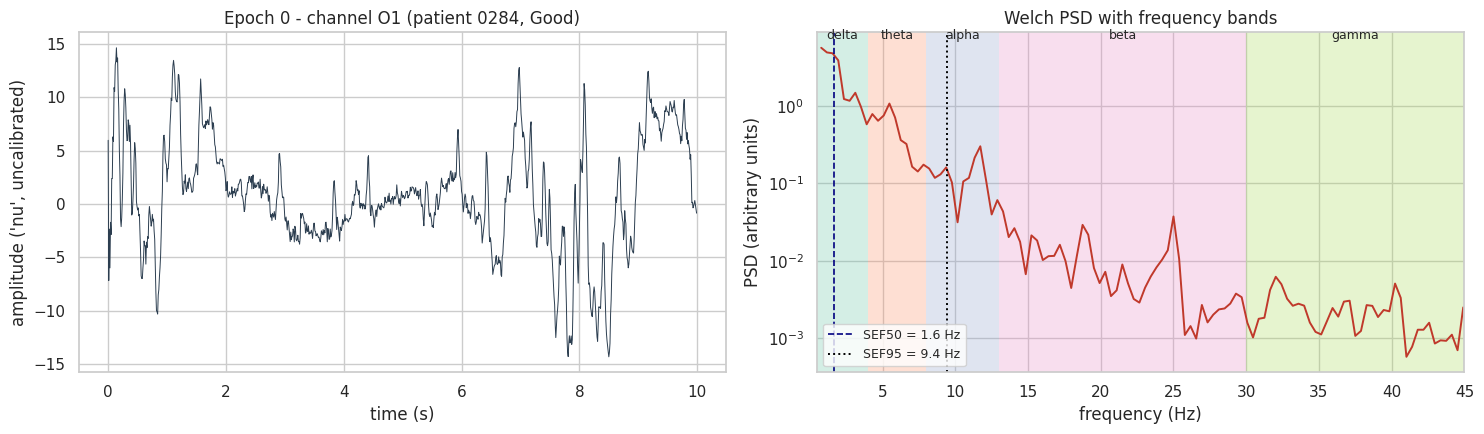

relative band powers of this epoch/channel:
  rel_delta  = 0.7713
  rel_theta  = 0.1605
  rel_alpha  = 0.0516
  rel_beta   = 0.0139
  rel_gamma  = 0.0026
  sum      = 1.000000  (must be 1.0)


In [7]:
EXAMPLE_EPOCH, EXAMPLE_CHANNEL = 0, "O1"
ch_idx = epochs_demo.ch_names.index(EXAMPLE_CHANNEL)
pid_demo = str(epochs_demo.metadata["patient_id"].iloc[0])
outcome_demo = str(epochs_demo.metadata["outcome"].iloc[0])

freqs, psd = F.compute_welch_psd(data_demo[EXAMPLE_EPOCH : EXAMPLE_EPOCH + 1])
psd_ch = psd[0, ch_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

times = np.arange(data_demo.shape[-1]) / F.TARGET_SFREQ_HZ
axes[0].plot(times, data_demo[EXAMPLE_EPOCH, ch_idx], lw=0.7, color="#2c3e50")
axes[0].set(xlabel="time (s)", ylabel="amplitude ('nu', uncalibrated)",
            title=f"Epoch {EXAMPLE_EPOCH} - channel {EXAMPLE_CHANNEL} (patient {pid_demo}, {outcome_demo})")

band_colors = dict(zip(F.FREQ_BANDS, sns.color_palette("Set2", len(F.FREQ_BANDS))))
for band, (lo, hi) in F.FREQ_BANDS.items():
    axes[1].axvspan(lo, hi, color=band_colors[band], alpha=0.28, lw=0)
    axes[1].text((lo + hi) / 2, psd_ch.max() * 1.3, band, ha="center", fontsize=9)
axes[1].semilogy(freqs, psd_ch, color="#c0392b", lw=1.4)

sef95 = F.spectral_edge_frequency(freqs, psd[0:1, ch_idx : ch_idx + 1], 0.95)[0, 0]
sef50 = F.spectral_edge_frequency(freqs, psd[0:1, ch_idx : ch_idx + 1], 0.50)[0, 0]
axes[1].axvline(sef50, color="navy", ls="--", lw=1.2, label=f"SEF50 = {sef50:.1f} Hz")
axes[1].axvline(sef95, color="black", ls=":", lw=1.4, label=f"SEF95 = {sef95:.1f} Hz")
axes[1].set(xlabel="frequency (Hz)", ylabel="PSD (arbitrary units)",
            xlim=F.PSD_BAND_HZ, title="Welch PSD with frequency bands")
axes[1].legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

rel_demo = F.relative_band_powers(freqs, psd)
print("relative band powers of this epoch/channel:")
for band in F.FREQ_BANDS:
    print(f"  rel_{band:<6s} = {rel_demo['rel_' + band][0, ch_idx]:.4f}")
print(f"  sum      = {sum(rel_demo['rel_' + b][0, ch_idx] for b in F.FREQ_BANDS):.6f}  (must be 1.0)")

## 4. Distribuciones por clase

Vista **por época** (34 000 puntos). Es la vista optimista: las épocas del mismo paciente están
muy correlacionadas entre sí, así que una separación bonita aquí **no** implica que el modelo
vaya a distinguir pacientes. El juicio de verdad es la sección 6.

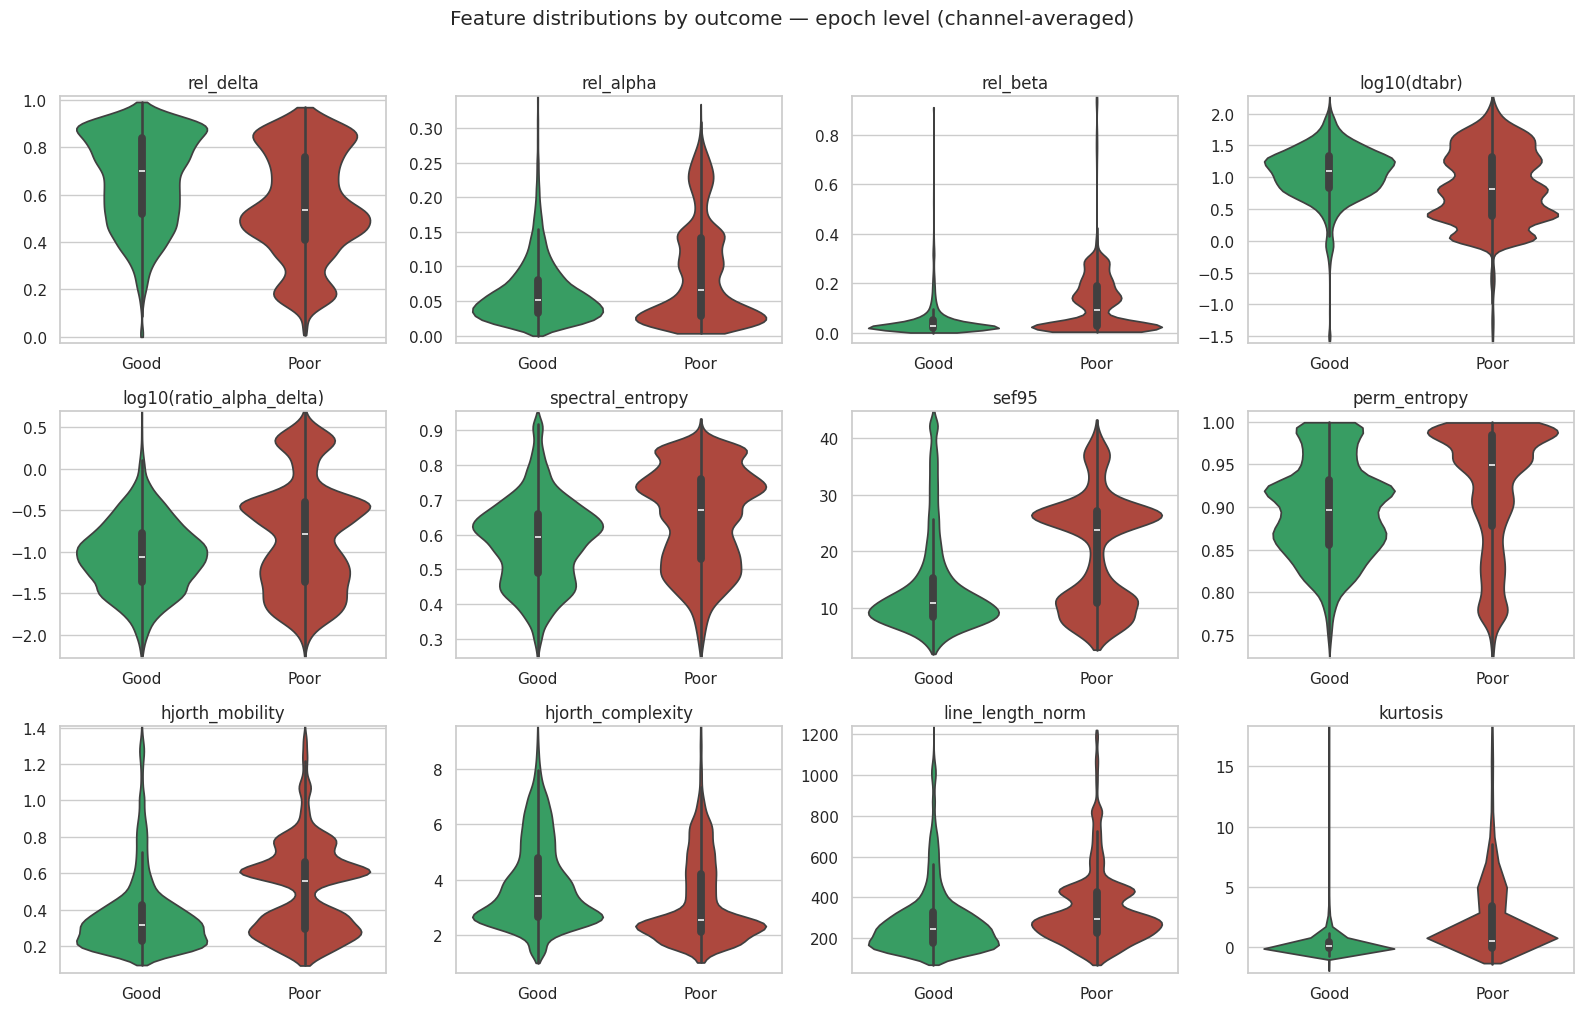

In [8]:
KEY_FEATURES = ["rel_delta", "rel_alpha", "rel_beta", "dtabr", "ratio_alpha_delta",
                "spectral_entropy", "sef95", "perm_entropy", "hjorth_mobility",
                "hjorth_complexity", "line_length_norm", "kurtosis"]

# Los ratios son estrictamente positivos y con colas de varios órdenes de magnitud:
# en escala lineal el violín se aplasta contra el eje, así que se pasan a log10.
LOG_SCALE = {"dtabr", "ratio_alpha_delta"}

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, feat in zip(axes.ravel(), KEY_FEATURES):
    plot_df = avg[[feat, "outcome"]].copy()
    if feat in LOG_SCALE:
        plot_df[feat] = np.log10(plot_df[feat])
    sns.violinplot(data=plot_df, x="outcome", y=feat, hue="outcome",
                   order=["Good", "Poor"], hue_order=["Good", "Poor"],
                   palette={"Good": "#27ae60", "Poor": "#c0392b"},
                   cut=0, legend=False, ax=ax)
    # Recorte robusto del eje vertical: features como la curtosis tienen colas extremas
    # que, sin recortar, dejan el cuerpo de la distribución invisible.
    lo, hi = np.percentile(plot_df[feat], [0.2, 99.8])
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))
    ax.set(xlabel="", ylabel="", title=f"log10({feat})" if feat in LOG_SCALE else feat)
fig.suptitle("Feature distributions by outcome — epoch level (channel-averaged)", y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlación entre features

Importa por dos razones prácticas para la Fase 4: (a) features casi idénticas inflan la
dimensionalidad sin aportar información, y (b) la regresión logística y el SVM lineal sufren con
predictores muy colineales. Se muestra la correlación de **Spearman** (por rangos, robusta a las
colas largas de los ratios) entre las 20 familias promediadas por canal.

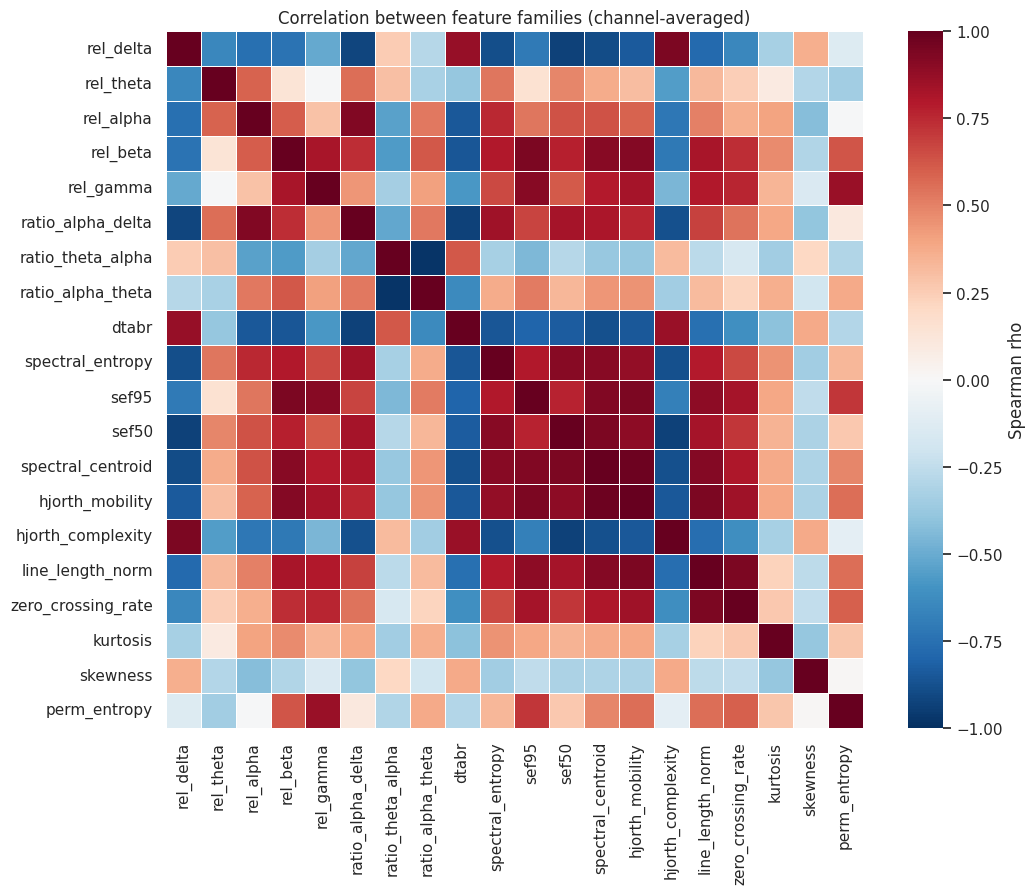

Most redundant feature pairs (|rho| > 0.9):
ratio_theta_alpha  ratio_alpha_theta    -0.980146
spectral_centroid  hjorth_mobility       0.978951
rel_delta          hjorth_complexity     0.943978
hjorth_mobility    line_length_norm      0.943408
sef50              spectral_centroid     0.940457
line_length_norm   zero_crossing_rate    0.940250
sef95              hjorth_mobility       0.938476
rel_beta           sef95                 0.937907
rel_delta          sef50                -0.936735
ratio_alpha_delta  dtabr                -0.934757
sef50              hjorth_complexity    -0.931796
rel_alpha          ratio_alpha_delta     0.929219
sef95              spectral_centroid     0.925972
spectral_centroid  line_length_norm      0.918089
rel_delta          ratio_alpha_delta    -0.915351
rel_beta           hjorth_mobility       0.914188
spectral_entropy   sef50                 0.911998
                   spectral_centroid     0.911658
rel_beta           spectral_centroid     0.907862
rel_ga

In [9]:
corr = avg[F.feature_names()].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Correlation between feature families (channel-averaged)")
plt.tight_layout()
plt.show()

# Pares casi redundantes: candidatos a podar en la Fase 4.
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Most redundant feature pairs (|rho| > 0.9):")
print(pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False).to_string())

In [10]:
# Correlación ENTRE CANALES de una misma familia: ¿aportan los 19 canales información distinta,
# o el CAR los ha dejado casi idénticos? Si fueran casi idénticos, 380 columnas serían un espejismo.
for feat in ["rel_delta", "perm_entropy"]:
    cols = [c for c in df.columns if c.rsplit("_", 1)[0] == feat]
    ch_corr = df[cols].corr(method="spearman").to_numpy()
    off_diag = ch_corr[np.triu_indices_from(ch_corr, k=1)]
    print(f"{feat:<16s} inter-channel rho: median={np.median(off_diag):.3f}  "
          f"min={off_diag.min():.3f}  max={off_diag.max():.3f}")

rel_delta        inter-channel rho: median=0.826  min=0.704  max=0.960
perm_entropy     inter-channel rho: median=0.821  min=0.659  max=0.941


## 6. Comparación por paciente — el nivel de análisis que cuenta

El objetivo clínico es un pronóstico **por paciente**, y el tamaño de muestra real es **17**, no
34 000 (finding 021 §3.4). Aquí se promedia cada feature dentro de cada paciente y se comparan los
**9 good contra los 8 poor**. Con N=17 esto es un *sanity check* de separabilidad, **no** una
prueba de hipótesis: no se ajusta ningún modelo ni se calculan p-valores que no soportarían una
corrección por 380 comparaciones.

In [11]:
per_patient = avg.groupby("patient_id").agg(
    {**{f: "mean" for f in F.feature_names()}, "outcome": "first", "label": "first"}
)

good = per_patient[per_patient.label == 1]
poor = per_patient[per_patient.label == 0]


def rank_biserial_auc(a: pd.Series, b: pd.Series) -> float:
    """AUC de Mann-Whitney: probabilidad de que un paciente 'good' supere a uno 'poor'.

    0.5 = sin separación; 0 o 1 = separación perfecta. Es una medida de tamaño de efecto,
    no una prueba de significancia — con 9 vs 8 pacientes no hay potencia para eso.
    """
    comparisons = (a.to_numpy()[:, None] > b.to_numpy()[None, :]).astype(float)
    ties = (a.to_numpy()[:, None] == b.to_numpy()[None, :]).astype(float)
    return float((comparisons + 0.5 * ties).mean())


summary = pd.DataFrame({
    "good_mean": good[F.feature_names()].mean(),
    "poor_mean": poor[F.feature_names()].mean(),
    "auc_good_vs_poor": [rank_biserial_auc(good[f], poor[f]) for f in F.feature_names()],
})
summary["separation"] = (summary.auc_good_vs_poor - 0.5).abs() * 2
summary = summary.sort_values("separation", ascending=False)
summary.style.format("{:.3f}").background_gradient(subset=["separation"], cmap="YlOrRd")

,good_mean,poor_mean,auc_good_vs_poor,separation
spectral_centroid,4.849,6.890,0.278,0.444
sef95,13.647,20.053,0.278,0.444
sef50,3.209,4.578,0.319,0.361
hjorth_mobility,0.373,0.511,0.319,0.361
rel_delta,0.669,0.556,0.667,0.333
ratio_alpha_delta,0.151,0.455,0.347,0.306
rel_beta,0.050,0.120,0.347,0.306
hjorth_complexity,3.846,3.208,0.653,0.306
spectral_entropy,0.582,0.649,0.361,0.278
rel_gamma,0.028,0.041,0.361,0.278


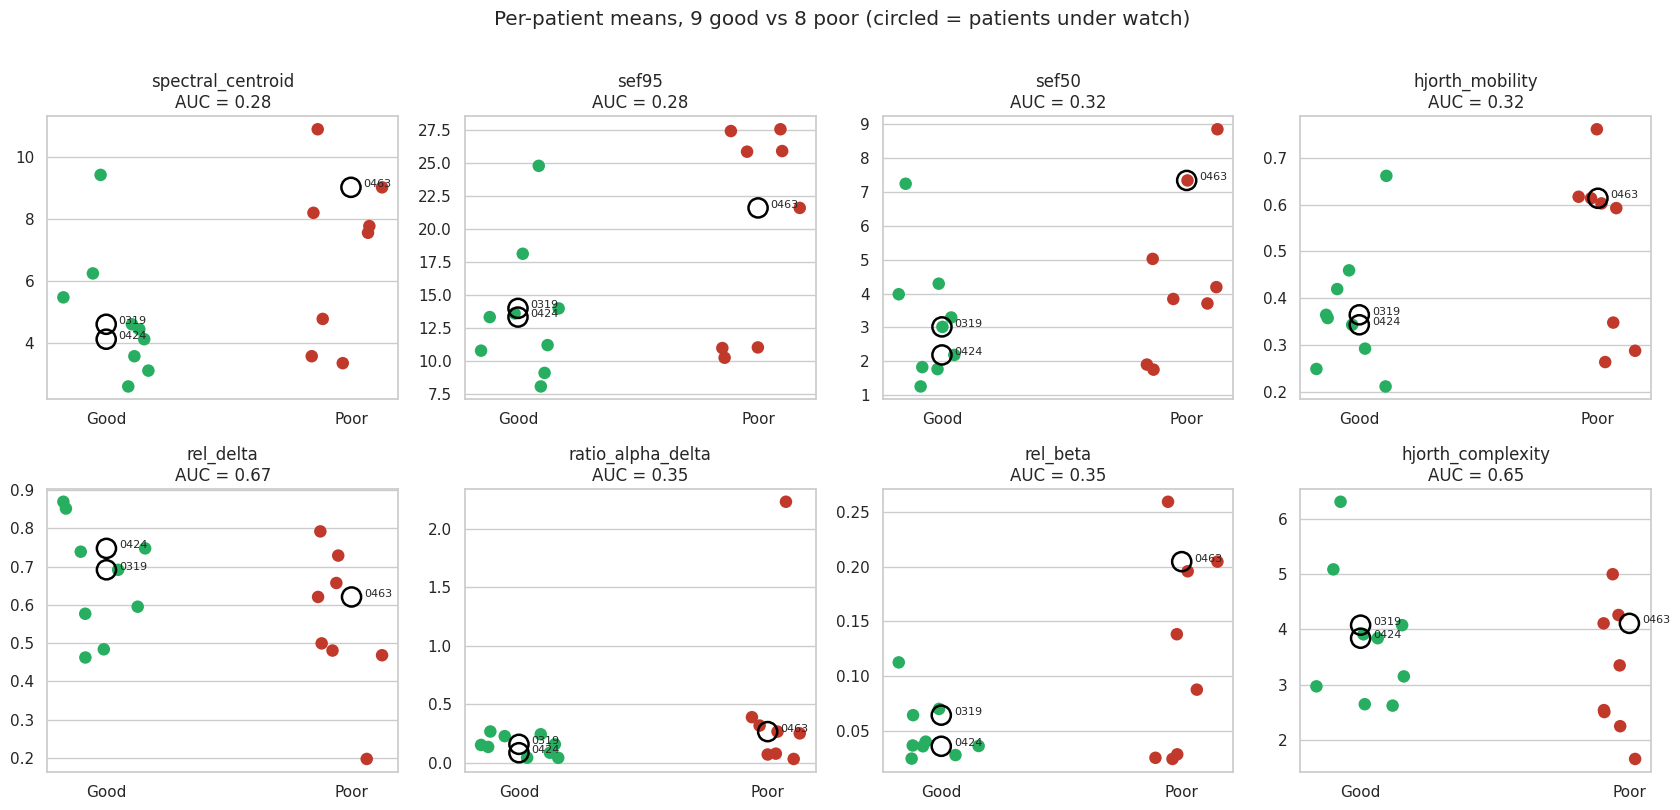

In [12]:
# Los pacientes bajo vigilancia (finding 020 §4 / 023): 0424 y 0319 tuvieron ~19 % y ~18 % de
# épocas planas por dropout global, y 0463 fue el único afectado por el fix del CAR/canal-plano.
# Se marcan en el gráfico para ver si sus features quedan fuera de la nube de su clase.
WATCHED = ["0424", "0319", "0463"]
TOP_N = 8
top_feats = summary.index[:TOP_N]

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, feat in zip(axes.ravel(), top_feats):
    sns.stripplot(data=per_patient.reset_index(), x="outcome", y=feat, hue="outcome",
                  order=["Good", "Poor"], hue_order=["Good", "Poor"],
                  palette={"Good": "#27ae60", "Poor": "#c0392b"},
                  size=9, jitter=0.18, legend=False, ax=ax)
    for pid in WATCHED:
        if pid in per_patient.index:
            row = per_patient.loc[pid]
            x = 0 if row.outcome == "Good" else 1
            ax.scatter([x], [row[feat]], s=190, facecolors="none",
                       edgecolors="black", linewidths=1.8, zorder=5)
            ax.annotate(pid, (x, row[feat]), xytext=(9, 0), textcoords="offset points", fontsize=8)
    ax.set(xlabel="", ylabel="", title=f"{feat}\nAUC = {summary.loc[feat, 'auc_good_vs_poor']:.2f}")
fig.suptitle("Per-patient means, 9 good vs 8 poor (circled = patients under watch)", y=1.01)
plt.tight_layout()
plt.show()

### Lectura honesta de la separabilidad

Tres cosas que conviene dejar escritas antes de pasar a la Fase 4:

**1. Ninguna feature separa con fuerza a nivel de paciente.** La mejor llega a un AUC de ~0.28
(equivalente a 0.72 con el signo invertido). Con 9 contra 8 pacientes, la desviación típica del
AUC bajo la hipótesis nula es ≈0.14, así que ese valor está a ~1.5 desviaciones del azar — y se
han mirado 20 familias. **No hay aquí ninguna separación estadísticamente sólida.** Esto es una
mala noticia para la potencia del modelo, pero una **buena noticia metodológica**: si alguna
feature hubiera salido con AUC ≈0.95 sobre 17 pacientes, lo primero que habría que sospechar es
un artefacto o una fuga, no un hallazgo.

**2. El signo del efecto es clínicamente contraintuitivo, y hay que decirlo.** Los pacientes de
mal pronóstico salen con espectro **más rápido** (mayor centroide, mayor SEF95, mayor movilidad de
Hjorth, más potencia relativa en beta) y **menos delta relativa**. La expectativa clínica es la
contraria: el daño anóxico lentifica el EEG. Dos explicaciones plausibles, ninguna descartada aún:

- **Artefacto muscular / mioclonías.** El estatus mioclónico es en sí mismo un marcador de mal
  pronóstico, y contamina la señal con EMG de banda ancha que empuja beta y gamma hacia arriba.
  Si es esto, la feature "funciona" por una razón real pero indirecta, y hay que declararlo.
- **Supresión de fondo.** En un EEG muy suprimido, lo que queda es ruido de banda ancha; en
  potencia *relativa* eso se traduce en un espectro aparentemente "rápido" aunque el cerebro esté
  casi silencioso. Es un límite conocido de las features relativas y encaja con el mal pronóstico.

Se comprobó que **no** es un simple efecto de amplitud: la correlación entre la amplitud típica
del paciente y sus features rápidas es prácticamente nula (|rho| < 0.15).

**3. Los pacientes bajo vigilancia salen limpios.** `0424` y `0319` —los del ~19 % y ~18 % de
épocas planas por *dropout* global— resultan ser los **menos** atípicos de los 17 en la tabla de
arriba. Es decir: el rechazo de épocas de la Fase 2 hizo su trabajo y las épocas que sobrevivieron
no arrastran la huella del *dropout*. `0463` (el único paciente afectado por el fix del CAR/canal
plano) queda a mitad de tabla. Los que sí destacan son otros: `0337` (Good, con beta y gamma muy
altas — candidato a contaminación por EMG) y `0348` (Poor, con una delta relativa de solo 0.20,
muy fuera del patrón de un coma post-anóxico).

In [13]:
# ¿Son los pacientes vigilados atípicos DENTRO de su propia clase? Se mide con un z-score
# robusto calculado sobre los pacientes de la misma clase (mediana y MAD, igual criterio que
# el rechazo de épocas de la Fase 2).
rows = []
for pid in per_patient.index:
    same_class = per_patient[per_patient.outcome == per_patient.loc[pid, "outcome"]]
    vals = same_class[F.feature_names()]
    med, mad = vals.median(), (vals - vals.median()).abs().median()
    z = (per_patient.loc[pid, F.feature_names()] - med) / (1.4826 * mad.replace(0, np.nan))
    rows.append({"patient_id": pid, "outcome": per_patient.loc[pid, "outcome"],
                 "median_|z|": float(z.abs().median()), "max_|z|": float(z.abs().max()),
                 "n_features_|z|>3": int((z.abs() > 3).sum())})
outliers = pd.DataFrame(rows).sort_values("median_|z|", ascending=False)
print(outliers.to_string(index=False))
print("\nWatched patients:", WATCHED)

patient_id outcome  median_|z|   max_|z|  n_features_|z|>3
      0337    Good    1.936632  5.840898                 7
      0422    Good    1.189471  2.038162                 0
      0348    Poor    1.177285  8.538716                 2
      0284    Good    0.931138  3.732900                 1
      0344    Poor    0.902169  2.778395                 0
      0463    Poor    0.690979  4.783617                 2
      0311    Good    0.674491 14.608178                 2
      0335    Good    0.674491  5.716561                 1
      0286    Good    0.669630  2.569633                 0
      0525    Poor    0.651819  2.288067                 0
      0371    Poor    0.581253  1.868148                 0
      0299    Good    0.578984  6.051636                 2
      0418    Poor    0.547086  1.467616                 0
      0346    Poor    0.476524  4.096965                 1
      0406    Poor    0.464176  3.179456                 1
      0424    Good    0.175217  3.738636                

## 7. Qué se lleva la Fase 4

- `data_processed/features.parquet` — 34 000 filas × 384 columnas, sin NaN ni inf.
- `patient_id` es el vector `groups` de la validación cruzada agrupada; `label` es la `y`.
- Las 380 columnas de feature son **todas invariantes a escala** (sección 2), así que ninguna
  codifica la calibración del equipo del paciente.
- Dos advertencias que viajan con la matriz:
  1. **380 features frente a 17 pacientes efectivos.** La separabilidad de la sección 6 se mide
     sobre los mismos 17 sujetos con los que se entrenará; elegir features mirando esa tabla sería
     una fuga. Cualquier selección de features debe ocurrir **dentro** de cada fold (finding 021 §3.5).
  2. **Redundancia alta** entre familias (sección 5): conviene regularización fuerte o una poda
     de correlación hecha, también, dentro del fold.